# Null network models

The human connectome has a complex topology, that we characterize using tools and techniques from network science.
This approach gives us properties of this connectome that we care about. Maybe it has modules, or specific regions that are well placed to broadcast or receive activity, or it supports a specific state transition particularly efficiently. Given these properties, the question becomes: *are these features in the brain special or are they generic to any network?*

Just like in brain maps (see [Spatial null models](null_models.ipynb)), the obvious answer of shuffling the edges and recomputing the metrics turns out to be the wrong one, because it
throws away an important fact about brain networks: they are spatially embedded. This tutorial explains that
property, and demonstrates a null that respects it.

This tutorial is the companion to [Spatial null models](null_models.ipynb), which permutes a parcel-wise
**map**. Here we permute the **network**. The distinction is simply what your statistic is a
property of: a correlation between two brain maps needs a map null, and modularity or control
energy from a connectome needs a network null.

## Two ingredients

A weighted connectome, and the distance between every pair of its nodes.

Both come from {mod}`snaplab_tools.datasets` and the bundled Schaefer geometry, so this notebook
runs anywhere. Substitute your own connectome and everything below works unchanged.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import bct

from snaplab_tools.datasets import make_connectome, schaefer_systems
from snaplab_tools.nulls import (
    load_distance_matrix,      # bundled Euclidean / geodesic parcel distance matrices
    geomsurr,                  # the three geometry-preserving null network models
    generate_network_nulls,    # permute -> recompute -> collect, over many permutations
)
from snaplab_tools.stats import get_null_p, get_fdr_p
from snaplab_tools.plotting.plotting import null_plot
from snaplab_tools.plotting.utils import set_plotting_params

set_plotting_params()

N_REGIONS = 200
N_PERMS = 1000

:::{important}
Use **Euclidean** centroid distances here, not the geodesic matrix.

{func}`~snaplab_tools.nulls.load_distance_matrix` will give you either. The geodesic basis is the
right one for *map* nulls — see the [spatial null models](null_models.ipynb) tutorial for why — but
geodesic paths do not cross the midline, so that matrix is `NaN` across hemispheres. A connectome
has plenty of cross-hemisphere edges, and {func}`~snaplab_tools.nulls.geomsurr` needs a finite
distance for every edge it fits. It will raise if you pass the geodesic matrix.
:::

In [2]:
W = make_connectome(n_regions=N_REGIONS, seed=0)
D, _ = load_distance_matrix(N_REGIONS, kind="euclidean")
systems = schaefer_systems(N_REGIONS)

triu = np.triu_indices(N_REGIONS, k=1)
edges = W[triu] > 0

print(f"connectome     {W.shape}, {edges.mean():.0%} dense, weights in "
      f"[{W[W > 0].min():.3g}, {W.max():.3g}]")
print(f"distances      {D.shape}, up to {D.max():.0f} mm")
print(f"systems        {len(np.unique(systems))} Yeo networks")

connectome     (200, 200), 25% dense, weights in [0.382, 25.7]
distances      (200, 200), up to 166 mm
systems        7 Yeo networks


## Geometry is most of the connectome

Connectomes are spatially embedded: edge weight falls off with distance. Nearby regions
are connected strongly, distant regions weakly, and that single relationship reproduces a
surprising amount of connectome organisation ([Roberts et al.,
2016](https://doi.org/10.1016/j.neuroimage.2015.09.009)).

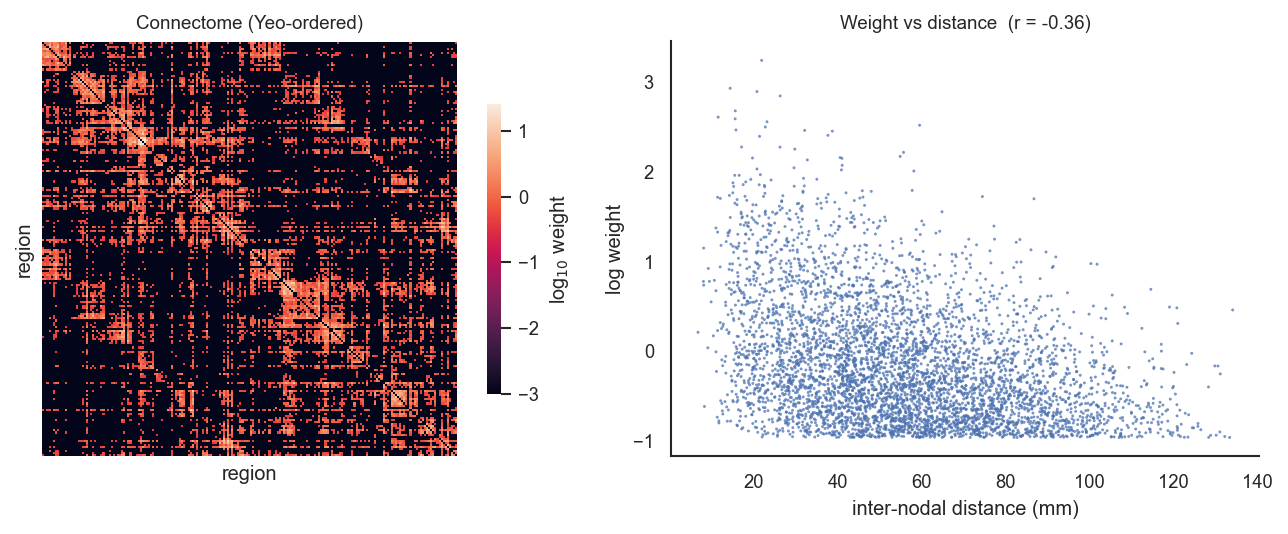

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), dpi=150)

sns.heatmap(np.log10(W + 1e-6), ax=axes[0], square=True, cmap="rocket", vmin=-3,
            cbar_kws={"label": "log$_{10}$ weight", "shrink": .7})
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_xlabel("region"); axes[0].set_ylabel("region")
axes[0].set_title("Connectome (Yeo-ordered)", fontsize=9)

d_edge, w_edge = D[triu][edges], W[triu][edges]
r_obs = np.corrcoef(np.log(w_edge), d_edge)[0, 1]
axes[1].scatter(d_edge, np.log(w_edge), s=2, alpha=.75, color="#4C72B0", edgecolor="none")
axes[1].set_xlabel("inter-nodal distance (mm)"); axes[1].set_ylabel("log weight")
axes[1].set_title(f"Weight vs distance  (r = {r_obs:.2f})", fontsize=9)
sns.despine(ax=axes[1])
plt.tight_layout(); plt.show()

Now watch what a naive edge shuffle does to it.

Permuting weights across edges at random is the null most people reach for first. It destroys the
weight–distance relationship completely: the permuted graph has long-range connections as strong as
short-range ones, which is not a brain. Any statistic that is even slightly sensitive to spatial
embedding will look wildly significant against it — you have tested "is my connectome different
from a network that could not physically exist?".

{func}`~snaplab_tools.nulls.geomsurr` instead fits log-weight as a function of distance, shuffles
the *residuals* around that fit, and inverts it. The relationship survives; which edge carries
which weight does not.

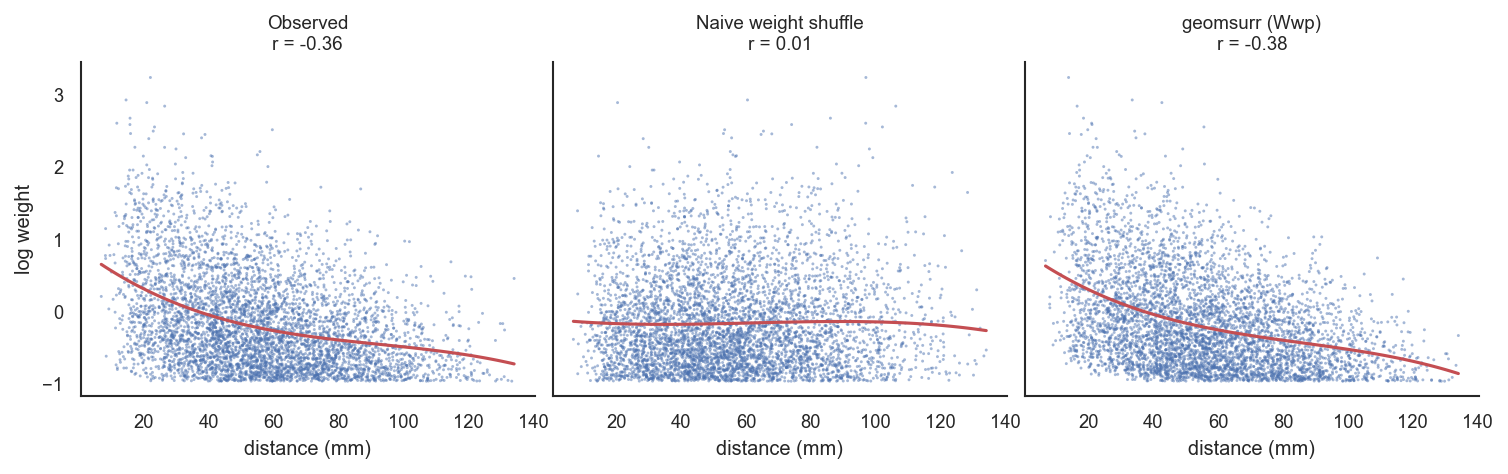

In [4]:
rng = np.random.default_rng(0)
W_naive = np.zeros_like(W)
W_naive[triu[0][edges], triu[1][edges]] = rng.permutation(w_edge)
W_naive += W_naive.T

Wwp, Wsp, Wssp = geomsurr(W, D, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=150, sharex=True, sharey=True)
for ax, (label, M) in zip(axes, [("Observed", W),
                                 ("Naive weight shuffle", W_naive),
                                 ("geomsurr (Wwp)", Wwp)]):
    m = M[triu] > 0
    d, lw = D[triu][m], np.log(M[triu][m])
    r = np.corrcoef(lw, d)[0, 1]
    ax.scatter(d, lw, s=2, alpha=.5, color="#4C72B0", edgecolor="none")
    coefs = np.polyfit(d, lw, 3)
    grid = np.linspace(d.min(), d.max(), 100)
    ax.plot(grid, np.polyval(coefs, grid), color="#C44E52", lw=1.5)
    ax.set_title(f"{label}\nr = {r:.2f}", fontsize=9)
    ax.set_xlabel("distance (mm)")
axes[0].set_ylabel("log weight")
sns.despine()
plt.tight_layout(); plt.show()

## Three null network models

{func}`~snaplab_tools.nulls.geomsurr` returns three permuted connectomes, in increasing order of how much they hold
fixed. All three preserve geometry; they differ in what they do about **node strength** (the sum of
a node's edge weights).

| | preserves | randomises | use when |
|---|---|---|---|
| `Wwp` | geometry, the exact multiset of edge weights | node strengths | you want the loosest of the three, or `W` is directed |
| `Wsp` | geometry, the *distribution* of strengths | which node holds which strength | asking whether the strength **distribution** explains your effect |
| `Wssp` | geometry, each node's **own** strength | everything else | asking whether the strength **sequence** explains it — the most conservative null |

The distinction is easiest to see by plotting each null's node strengths against the original.

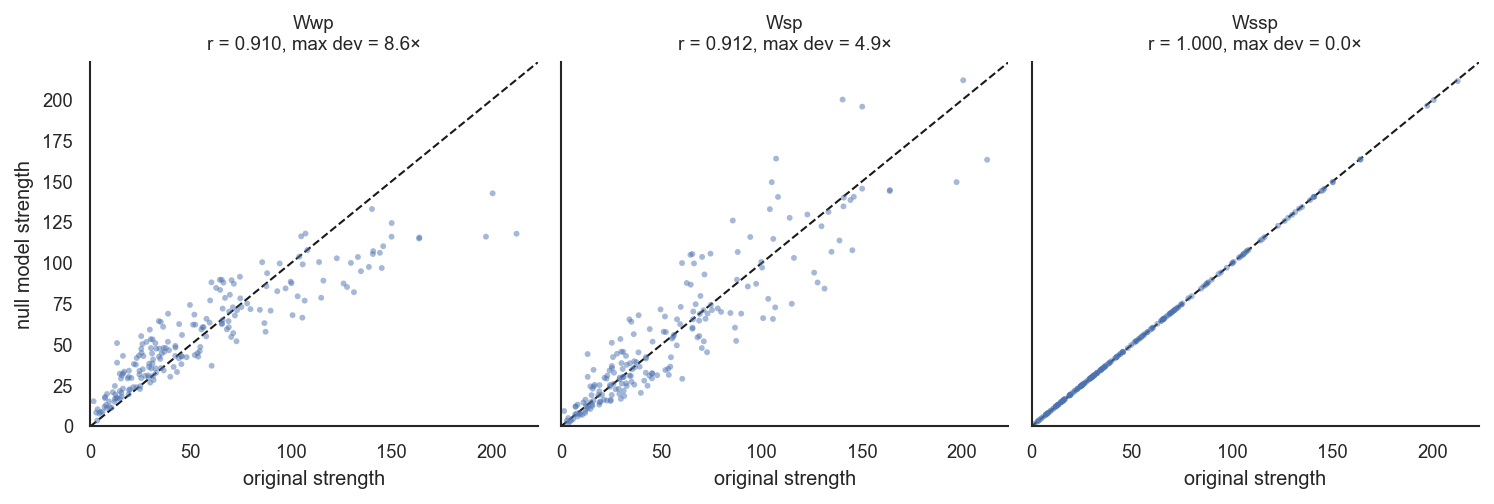

In [5]:
strength = W.sum(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), dpi=150, sharex=True, sharey=True)
for ax, (label, M) in zip(axes, [("Wwp", Wwp), ("Wsp", Wsp), ("Wssp", Wssp)]):
    s_surr = M.sum(axis=0)
    lim = [0, max(strength.max(), s_surr.max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=1, zorder=1)
    ax.scatter(strength, s_surr, s=8, alpha=.5, color="#4C72B0", edgecolor="none", zorder=2)
    ax.set_title(f"{label}\nr = {np.corrcoef(s_surr, strength)[0, 1]:.3f}, "
                 f"max dev = {np.max(np.abs(s_surr - strength) / strength):.1f}×", fontsize=9)
    ax.set_xlabel("original strength"); ax.set_xlim(lim); ax.set_ylim(lim)
axes[0].set_ylabel("null model strength")
sns.despine()
plt.tight_layout(); plt.show()

Only `Wssp` sits on the identity line — every node gets its own strength back.

`Wsp` is the instructive one. Its correlation with the original strengths is high, but individual
nodes are off by several-fold: it holds the same *set* of strengths and hands them to different
nodes, which is exactly what it is for. Note how misleading the correlation is as a summary here —
it is high because the strength range is wide, not because nodes kept their strengths.

:::{note}
`Wsp` and `Wssp` come out close together in *this* connectome, because geometry already pins down
most of the strength variance (`Wwp` correlates at r ≈ 0.9 with the original strengths without
trying to). That is a real property of spatially embedded networks rather than an artefact.

The strength restoration is also iterative rather than exact. At the default `n_iter=10` it lands
within ~0.2% of target, which is why `Wssp` shows a small non-zero deviation above. Raise `n_iter`
if a statistic is sensitive to that.
:::

## The edge set is fixed

The one thing to internalise before using these nulls.

`geomsurr` redistributes weights over the edges that already exist. It does not move, add, or
delete any. So the binary adjacency matrix — and the degree sequence, the binary path length, the
binary clustering coefficient — is **identical** between every permuted network and the original.

In [6]:
print("binary adjacency identical to observed:",
      all(np.array_equal(M > 0, W > 0) for M in (Wwp, Wsp, Wssp)))

# What that means if you test an unweighted statistic against this null:
mean_degree = lambda A: (A > 0).sum(axis=0).mean()
degree_null = generate_network_nulls(W, D, n_perms=50, kind="ssp",
                                     statistic=mean_degree, progress=False)

print(f"observed mean degree  {mean_degree(W):.2f}")
print(f"null spread           {degree_null.std():.3g}  <- zero variance: there is no null here")

binary adjacency identical to observed: True
observed mean degree  49.75
null spread           0  <- zero variance: there is no null here


:::{warning}
These are nulls for **weighted** statistics only. Testing a binary graph statistic against them
gives a zero-variance null distribution and a meaningless p-value — the permuted graph *is* the observed
graph as far as that statistic can tell. For a binary topology null you need genuine rewiring, such
as `bct.randmio_und`.
:::

## Testing a network-level statistic

For the purposes of this tutorial, let's ask the following question: are the Yeo systems more modular than geometry and strength can
account for?

The statistic is the modularity `Q` of the fixed Yeo partition — written out here rather than
imported. This is just for completeness, since modularity functions are all over the place in network science. Because the partition is fixed it is fully deterministic, which matters: a stochastic statistic would add variance to the null that has nothing to do with the permuted network.

In [7]:
def modularity(A, partition):
    """Newman-Girvan modularity of a *fixed* partition on a weighted graph."""
    strength = A.sum(axis=0)
    two_m = strength.sum()
    same_module = partition[:, None] == partition[None, :]
    expected = np.outer(strength, strength) / two_m
    return ((A - expected) * same_module).sum() / two_m


q_observed = modularity(W, systems)
print(f"observed Q = {q_observed:.4f}")

observed Q = 0.3384


{func}`~snaplab_tools.nulls.generate_network_nulls` runs the loop. Asking for several kinds of nulls costs
no extra work — all three null models fall out of one pass — so there is no reason to run it three
times.

It shows a progress bar by default, which is worth leaving on: a few thousand permuted graphs of a
400-node connectome takes minutes, and longer if the statistic is expensive. It is off below only so
this page stays readable.

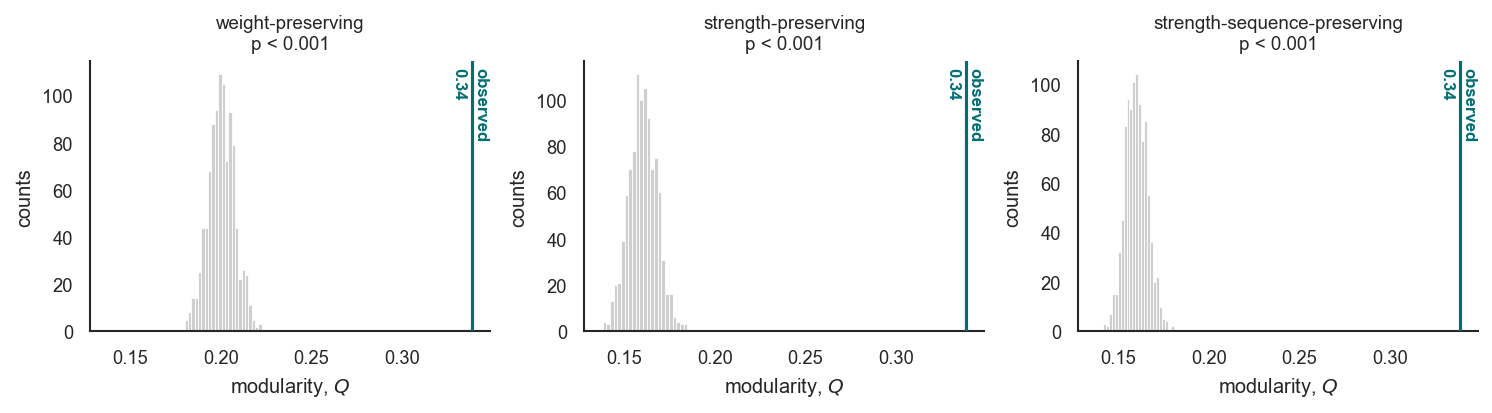

In [8]:
q_null = generate_network_nulls(
    W, D,
    n_perms=N_PERMS,
    kind=("wp", "sp", "ssp"),
    statistic=lambda A: modularity(A, systems),
    progress=False,          # a tqdm bar by default; off here to keep the page readable
)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), dpi=150, sharex=True)
titles = {"wp": "weight-preserving", "sp": "strength-preserving",
          "ssp": "strength-sequence-preserving"}
for ax, kind in zip(axes, ("wp", "sp", "ssp")):
    null = q_null[kind]
    p = get_null_p(q_observed, null, alternative="greater")
    # A p of 0 means "below what this null can resolve", so annotate the bound, not "p = 0".
    null_plot(observed=q_observed, null=null, xlabel="modularity, $Q$", ax=ax,
              p_val=p if p > 0 else None)
    label = f"p = {p:.3f}" if p > 0 else f"p < {1 / N_PERMS:.3f}"
    ax.set_title(f"{titles[kind]}\n{label}", fontsize=9)
plt.tight_layout(); plt.show()

The observed `Q` sits far outside all three nulls, so the system structure is not a by-product of
spatial embedding, nor of the strength distribution, nor of the strength sequence. With
`N_PERMS = 1000` surrogates the smallest resolvable p-value is 0.001, so this is reported as
`p < 0.001` — never as `p = 0`.

Reporting all three is worth the two extra lines: had `Q` survived `wp` but not `ssp`, the
conclusion would have been that the modularity is a consequence of how strength is distributed, not
of module structure as such.

## Testing a nodal statistic

Same machinery, one value per region instead of one per network, plus a correction for testing 200
of them. Here the statistic is each node's weighted clustering coefficient.

This is the shape of the average-controllability test in [Parkes et al.
(2024)](https://doi.org/10.1038/s41596-024-01023-w) — average controllability tracks node strength
closely, so `Wssp` is the null that makes it a real test rather than a restatement of the strength
map. `ave_control` lives in [nctpy](https://github.com/LindenParkesLab/nctpy); the pattern below is
identical.

In [9]:
cc_observed = bct.clustering_coef_wu(W)
cc_null = generate_network_nulls(W, D, n_perms=N_PERMS, kind="ssp",
                                 statistic=bct.clustering_coef_wu, progress=False)

p_nodal = np.array([get_null_p(cc_observed[i], cc_null[:, i], alternative="two-sided")
                    for i in range(N_REGIONS)])
p_fdr = get_fdr_p(p_nodal)
significant = p_fdr < 0.05

print(f"null shape                {cc_null.shape}  (permutations x regions)")
print(f"regions surviving BH-FDR  {significant.sum()} / {N_REGIONS}")

null shape                (1000, 200)  (permutations x regions)
regions surviving BH-FDR  88 / 200


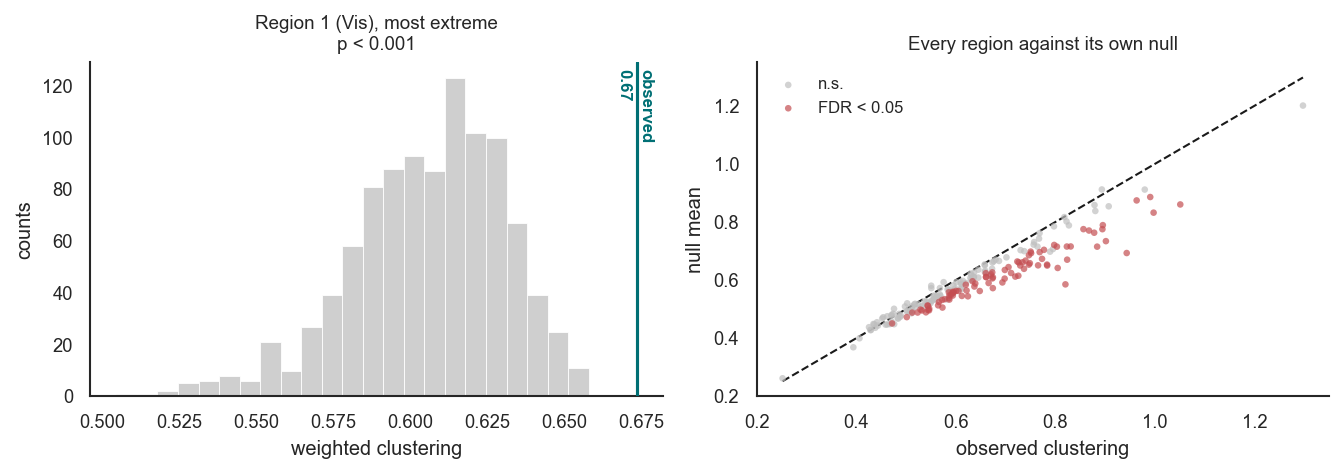

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), dpi=150)

node = int(np.argmin(p_fdr))
p_node = p_fdr[node]
null_plot(observed=cc_observed[node], null=cc_null[:, node],
          xlabel="weighted clustering", ax=axes[0],
          p_val=p_node if p_node > 0 else None)
label = f"p = {p_node:.3f}" if p_node > 0 else f"p < {1 / N_PERMS:.3f}"
axes[0].set_title(f"Region {node} ({systems[node]}), most extreme\n{label}", fontsize=9)

axes[1].plot([cc_observed.min(), cc_observed.max()], [cc_observed.min(), cc_observed.max()],
             "k--", lw=1, zorder=1)
for mask, color, label in [(~significant, "0.75", "n.s."),
                           (significant, "#C44E52", "FDR < 0.05")]:
    axes[1].scatter(cc_observed[mask], cc_null[:, mask].mean(axis=0), s=10, alpha=.7,
                    color=color, edgecolor="none", label=label, zorder=2)
axes[1].set_xlabel("observed clustering"); axes[1].set_ylabel("null mean")
axes[1].set_title("Every region against its own null", fontsize=9)
axes[1].legend(fontsize=8, frameon=False)
sns.despine(ax=axes[1])
plt.tight_layout(); plt.show()

Each region gets its own null distribution, its own p-value, and then a family-wise correction with
{func}`~snaplab_tools.stats.get_fdr_p`. Points below the identity line in the right panel are
regions that cluster *more* than their geometry and strength predict.

Two things this makes concrete. The effect runs one way — 180 of the 200 regions cluster more than
their own null predicts, and every one of the 88 that survives correction is in that direction. A
consistent sign across the cortex is itself informative: it says the module structure is global
rather than carried by a handful of regions.

And a nodal test is a family of 200 tests, so it needs correcting. Note also that many regions land
at the resolution floor, where the corrected p-value is reported as a bound — the same
`p < 1/n_perms` convention as above, applied per region.

## Getting the permuted graphs back

Every call so far handed `generate_network_nulls` a `statistic`, and got a null distribution back.
That is the memory-efficient path: each permuted graph is reduced to a number, or a vector of them,
and then discarded.

The `statistic` argument is optional. Leave it out and you get the permuted graphs themselves —
one per permutation, stacked into an array of shape `(n_perms, n_regions, n_regions)`. From there
you can do whatever you like with them.

In [11]:
graphs = generate_network_nulls(W, D, n_perms=25, kind="ssp", progress=False)

print(f"{graphs.shape}  (permutations x regions x regions)")
print(f"{graphs.nbytes / 1e6:.0f} MB in memory")

# Each slice is an ordinary connectome: symmetric, and — for 'ssp' — carrying the original
# strength sequence back to the ~0.2% the iterative correction converges to.
deviation = np.max(np.abs(graphs[0].sum(axis=0) - strength) / strength)
print(f"graphs[0]      symmetric = {np.array_equal(graphs[0], graphs[0].T)}, "
      f"max strength deviation = {deviation:.1%}")

(25, 200, 200)  (permutations x regions x regions)
8 MB in memory
graphs[0]      symmetric = True, max strength deviation = 1.5%


In [12]:
# The permuting is the expensive part, so one set of graphs can answer several questions.
q_from_graphs = np.array([modularity(A, systems) for A in graphs])
cc_from_graphs = np.array([bct.clustering_coef_wu(A).mean() for A in graphs])

print(f"modularity       null mean {q_from_graphs.mean():.4f}")
print(f"mean clustering  null mean {cc_from_graphs.mean():.4f}")

# Permuted graph i is built from seed + i either way, so this is exactly what passing
# statistic= would have computed — the two routes are not merely equivalent, they agree exactly.
q_direct = generate_network_nulls(W, D, n_perms=25, kind="ssp",
                                  statistic=lambda A: modularity(A, systems), progress=False)
print(f"\nidentical to the statistic= route: {np.array_equal(q_from_graphs, q_direct)}")

modularity       null mean 0.1592
mean clustering  null mean 0.5965

identical to the statistic= route: True


:::{warning}
Holding the graphs costs `n_perms × n_regions² × 8` bytes. That is nothing at the 25 permutations
above, but 1,000 permutations of this 200-region connectome is 0.32 GB, and the 5,000 permutations
of a 400-region connectome you would want for a real analysis is **6.4 GB**. Pass a `statistic`
unless you actually need the graphs, and keep `n_perms` small while you are exploring.
:::

But there are a few cases getting them back is probably worth the memory cost:

- **Several statistics from one set of permutations**, as above — no reason to permute once per
  statistic.
- **Handing them to another package.** `nctpy`, for instance, where control energy and average
  controllability both need their own normalisation step applied to each graph first.
- **Saving them to disk**, so a slow analysis can be re-run without permuting again.

Asking for several kinds of nulls without a `statistic` works too, and returns a dict of stacked graphs
rather than a dict of null distributions — with the memory cost multiplied by the number of kinds.

## What to report

- **The distance basis.** Euclidean centroid distances, and the resolution they were computed at.
- **Which null network model.** `Wwp`, `Wsp`, or `Wssp` — they are different nulls answering different
  questions, and "a geometry-preserving null" does not identify which.
- **`n_perms`, and the p-value bound it implies.** `p < 1/n_perms`, not `p = 0`.
- **That the statistic is weighted.** Given the fixed edge set, this is what makes the test valid at
  all.

## See also

- [Spatial null models](null_models.ipynb) — the map-based counterpart, and when to use it instead
- {func}`~snaplab_tools.nulls.geomsurr` — the generator, and the full description of each null network model
- {func}`~snaplab_tools.stats.get_null_p` — the p-value convention, including why 0 is a bound
- {func}`~snaplab_tools.datasets.make_connectome` — what the synthetic connectome here is made of